# Disparités de santé gynécologique — Analyse descriptive
**Dataset** : TidyTuesday 2025-02-25  
**Source** : `article_dat.csv` — articles scientifiques sur les inégalités de santé en gynécologie

## 0. Imports & chargement

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from graphic_drawer import GraphicDrawer

URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-02-25/article_dat.csv"
df = pd.read_csv(URL, low_memory=False)

print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head(3)

Dimensions : 318 lignes × 65 colonnes


,pmid,doi,jabbrv,journal,year,month,day,title,abstract,keywords,...,other_gyn_onc,endo,fibroids,other_gyn_surg,fert,matmorbmort,other_preg,phys_div,other,covid
0,31764726,10.1097/AOG.0000000000003552,Obstet Gynecol,Obstetrics and gynecology,2020,4,3,Desired Sterilization Procedure at the Time of...,To evaluate whether women with Medicaid are le...,Adult; Cesarean Section; Cohort Studies; Femal...,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,31492539,10.1016/j.ygyno.2019.08.013,Gynecol Oncol,Gynecologic oncology,2019,11,5,Medicaid and Medicare payer status are associa...,To compare postoperative outcomes by primary p...,Health disparities; Medicaid; Medicare; Outcom...,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,30890269,10.1016/j.ygyno.2019.03.007,Gynecol Oncol,Gynecologic oncology,2019,7,5,Identifying disparities in germline and somati...,Germline mutations occur in approximately 25% ...,"Adult; Aged; Aged, 80 and over; BRCA1 Protein;...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Publications par année — `draw_line_plot`

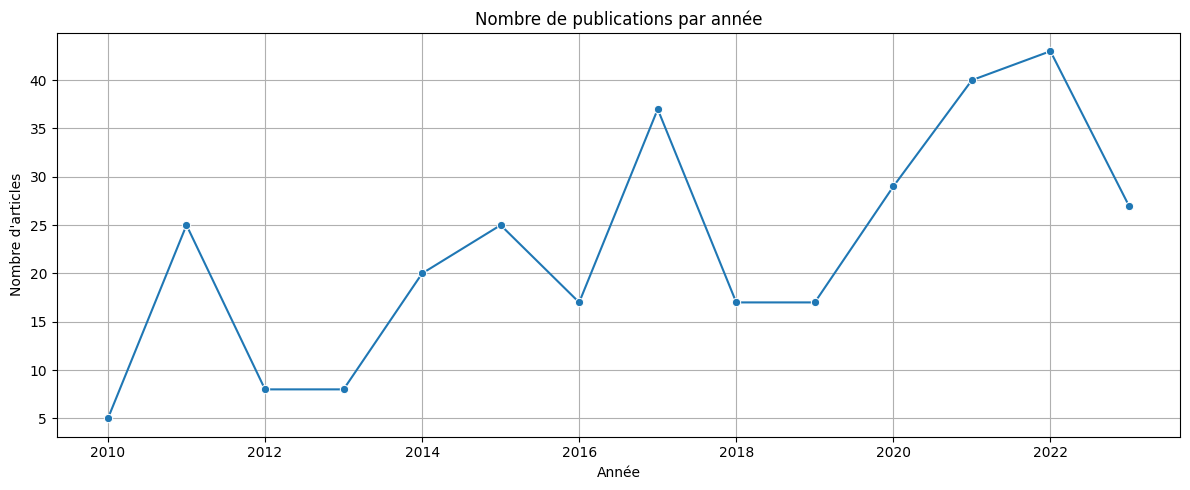

In [3]:
pubs_by_year = df.groupby("year").size().reset_index(name="Count")
pubs_by_year.columns = ["Category", "Count"]

GraphicDrawer.draw_line_plot(
    data=pubs_by_year,
    title="Nombre de publications par année",
    xlabel="Année",
    ylabel="Nombre d'articles",
    figsize=(12, 5),
)

## 2. Top 10 journaux — `draw_bar_plot`

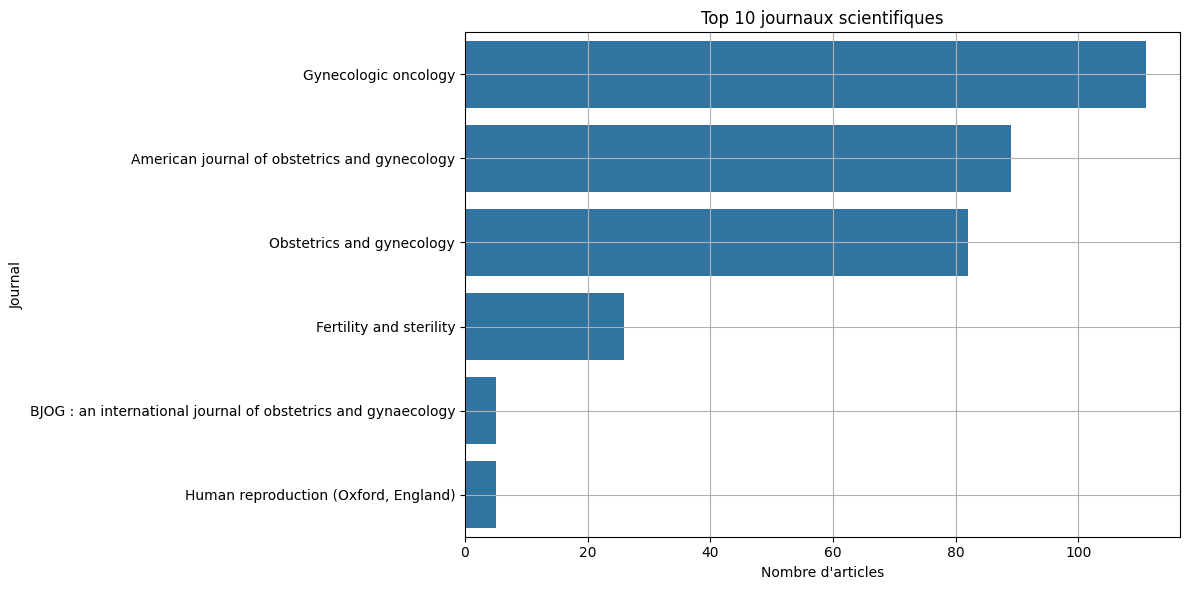

In [4]:
top_journals = (
    df["journal"]
    .value_counts()
    .head(10)
    .reset_index()
)
top_journals.columns = ["Category", "Count"]

GraphicDrawer.draw_bar_plot(
    data=top_journals,
    top_n=10,
    title="Top 10 journaux scientifiques",
    xlabel="Nombre d'articles",
    ylabel="Journal",
    figsize=(12, 6),
)

## 3. Types d'étude — `draw_pie_chart`

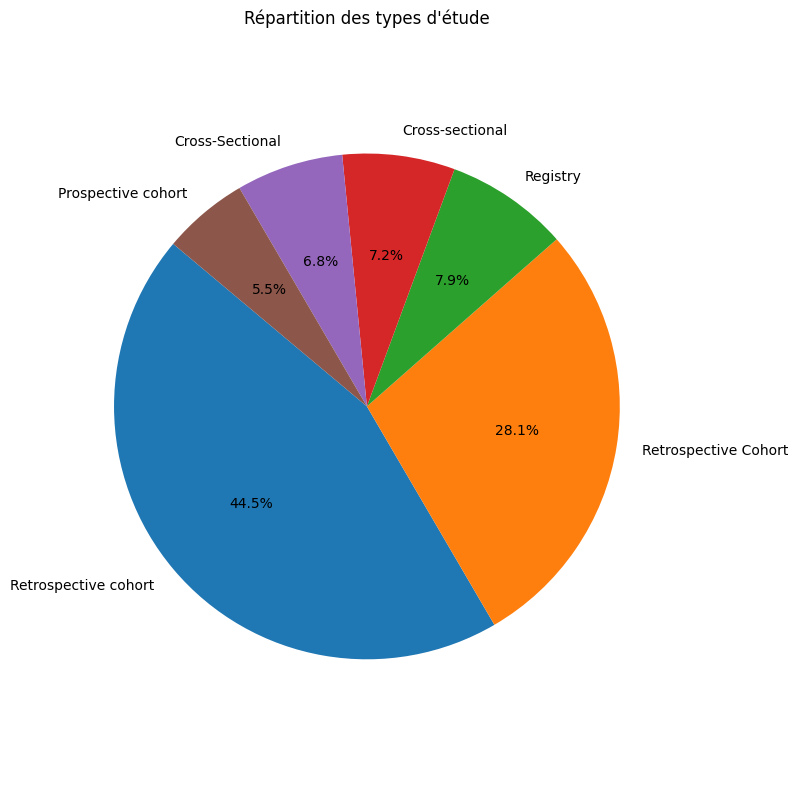

In [5]:
study_types = (
    df["study_type"]
    .value_counts()
    .head(6)
    .reset_index()
)
study_types.columns = ["Category", "Count"]

GraphicDrawer.draw_pie_chart(
    data=study_types,
    top_n=6,
    title="Répartition des types d'étude",
    figsize=(8, 8),
)

## 4. Durée des études — `draw_histogram`

Avant nettoyage : 313 valeurs
  Durées négatives : 2
  Min / Max brut  : -2109 / 2121
Après nettoyage  : 309 valeurs conservées
  Min / Max clean : 0 / 42
  Médiane          : 5.0 ans


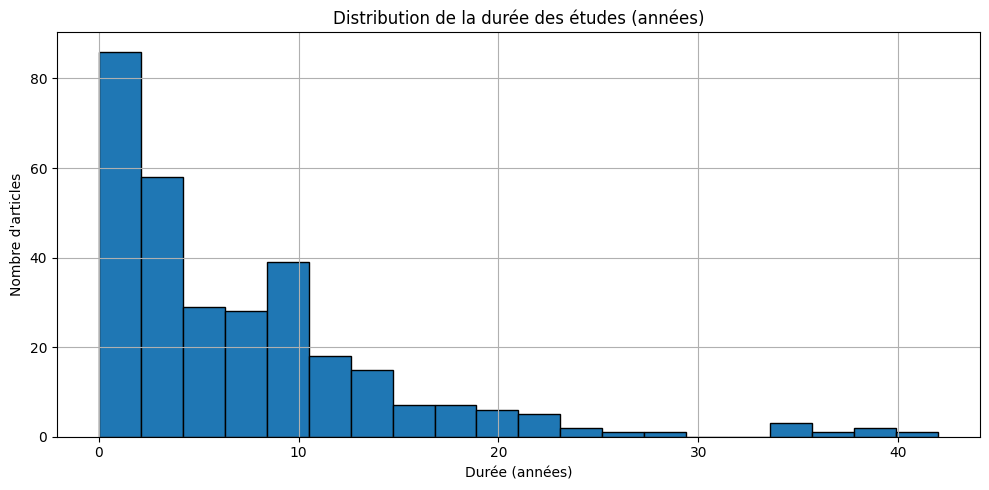

In [12]:
df["study_duration"] = df["study_year_end"] - df["study_year_start"]
duration_raw = df["study_duration"].dropna()

print(f"Avant nettoyage : {len(duration_raw)} valeurs")
print(f"  Durées négatives : {(duration_raw < 0).sum()}")
print(f"  Min / Max brut  : {duration_raw.min():.0f} / {duration_raw.max():.0f}")

# Suppression des durées négatives (saisie inversée) et des outliers (> 100 ans)
duration = duration_raw[(duration_raw >= 0) & (duration_raw <= 100)]

print(f"Après nettoyage  : {len(duration)} valeurs conservées")
print(f"  Min / Max clean : {duration.min():.0f} / {duration.max():.0f}")
print(f"  Médiane          : {duration.median():.1f} ans")

GraphicDrawer.draw_histogram(
    data=duration,
    bins=20,
    title="Distribution de la durée des études (années)",
    xlabel="Durée (années)",
    ylabel="Nombre d'articles",
    figsize=(10, 5),
)

## 5. Durée des études — `draw_box_plot`

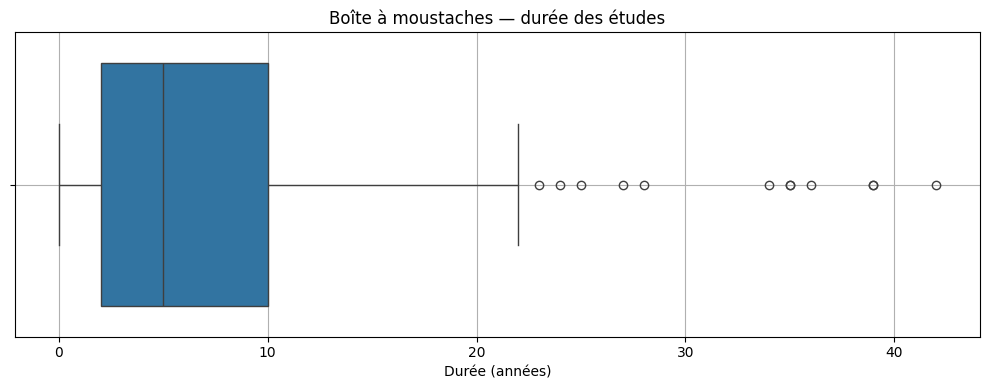

In [13]:
GraphicDrawer.draw_box_plot(
    data=duration,
    title="Boîte à moustaches — durée des études",
    xlabel="Durée (années)",
    figsize=(10, 4),
)

## 6. Domaines de recherche — `draw_bar_plot`

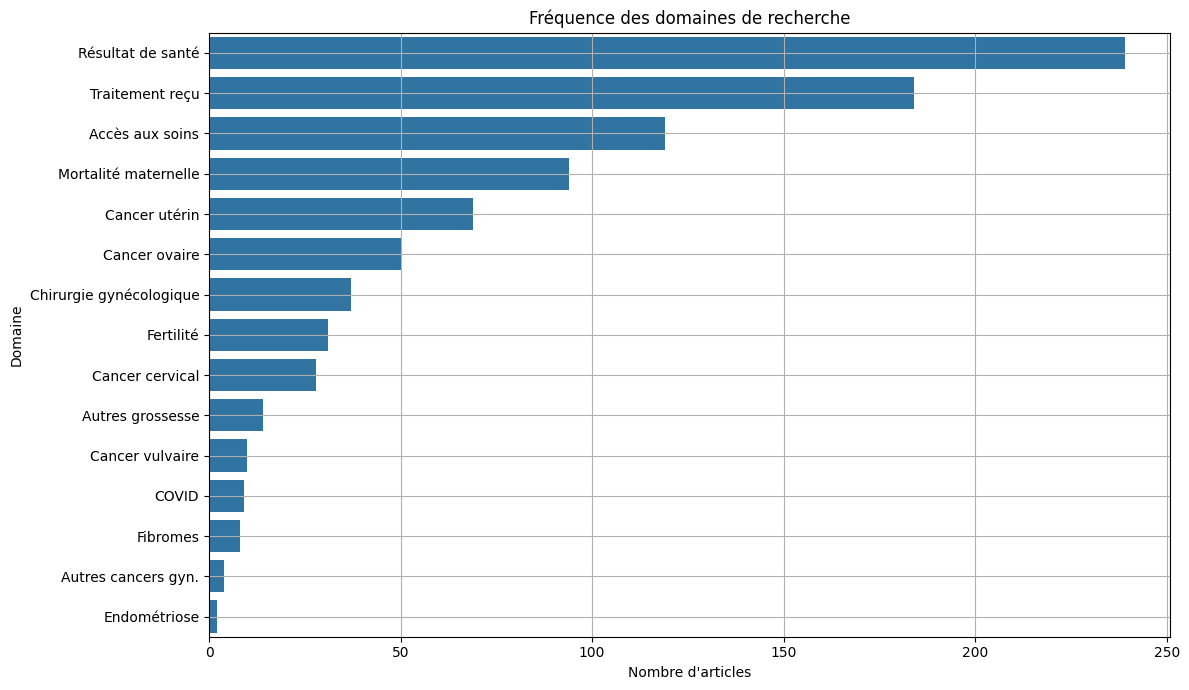

In [19]:
domain_map = {
    "cancer_ovarian":      "Cancer ovaire",
    "cancer_uterine":      "Cancer utérin",
    "cancer_cervical":     "Cancer cervical",
    "cancer_vulvar":       "Cancer vulvaire",
    "endo":                "Endométriose",
    "fibroids":            "Fibromes",
    "fert":                "Fertilité",
    "matmorbmort":         "Mortalité maternelle",
    "other_preg":          "Autres grossesse",
    "other_gyn_surg":      "Chirurgie gynécologique",
    "other_gyn_onc":       "Autres cancers gyn.",
    "access_to_care":      "Accès aux soins",
    "treatment_received":  "Traitement reçu",
    "health_outcome":      "Résultat de santé",
    "covid":               "COVID",
}

domain_counts = {
    label: int(df[col].sum())
    for col, label in domain_map.items()
    if col in df.columns
}
domain_df = (
    pd.Series(domain_counts)
    .sort_values(ascending=False)
    .reset_index()
)
domain_df.columns = ["Category", "Count"]

GraphicDrawer.draw_bar_plot(
    data=domain_df,
    top_n=15,
    title="Fréquence des domaines de recherche",
    xlabel="Nombre d'articles",
    ylabel="Domaine",
    figsize=(12, 7),
)

## 7. Groupes raciaux les plus étudiés — `draw_bar_plot`

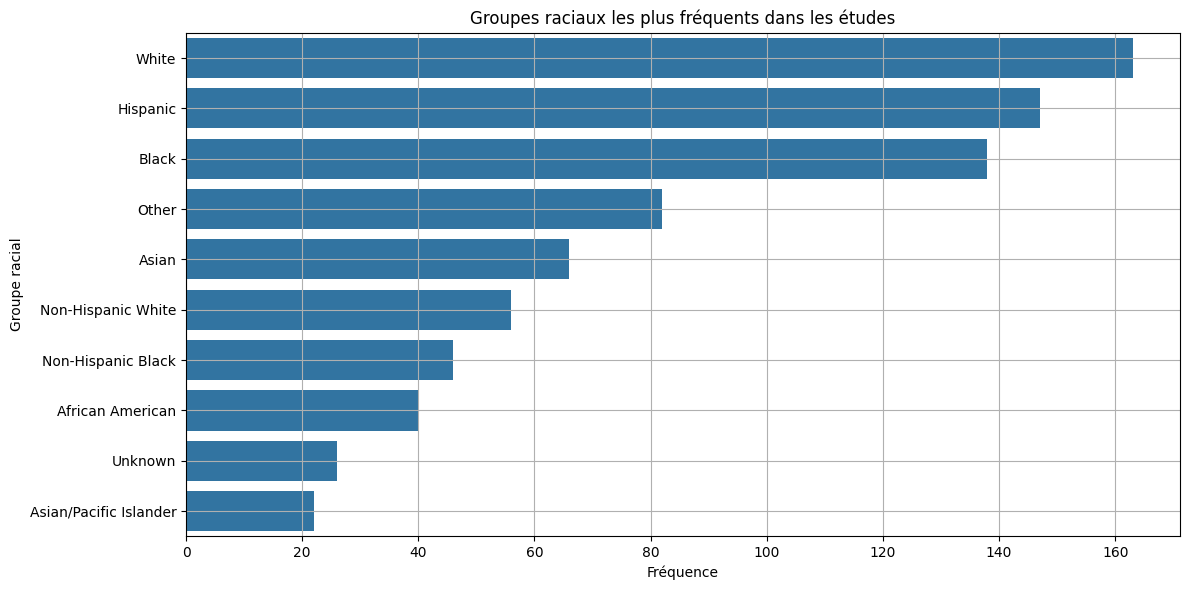

In [20]:
race_cols = [c for c in df.columns if c.startswith("race") and not c.endswith("_ss")]
race_counts = (
    pd.concat([df[c] for c in race_cols])
    .dropna()
    .value_counts()
    .reset_index()
)
race_counts.columns = ["Category", "Count"]

GraphicDrawer.draw_bar_plot(
    data=race_counts,
    top_n=10,
    title="Groupes raciaux les plus fréquents dans les études",
    xlabel="Fréquence",
    ylabel="Groupe racial",
    figsize=(12, 6),
)

## 9. Nuage de mots — titres des articles — `draw_wordcloud`

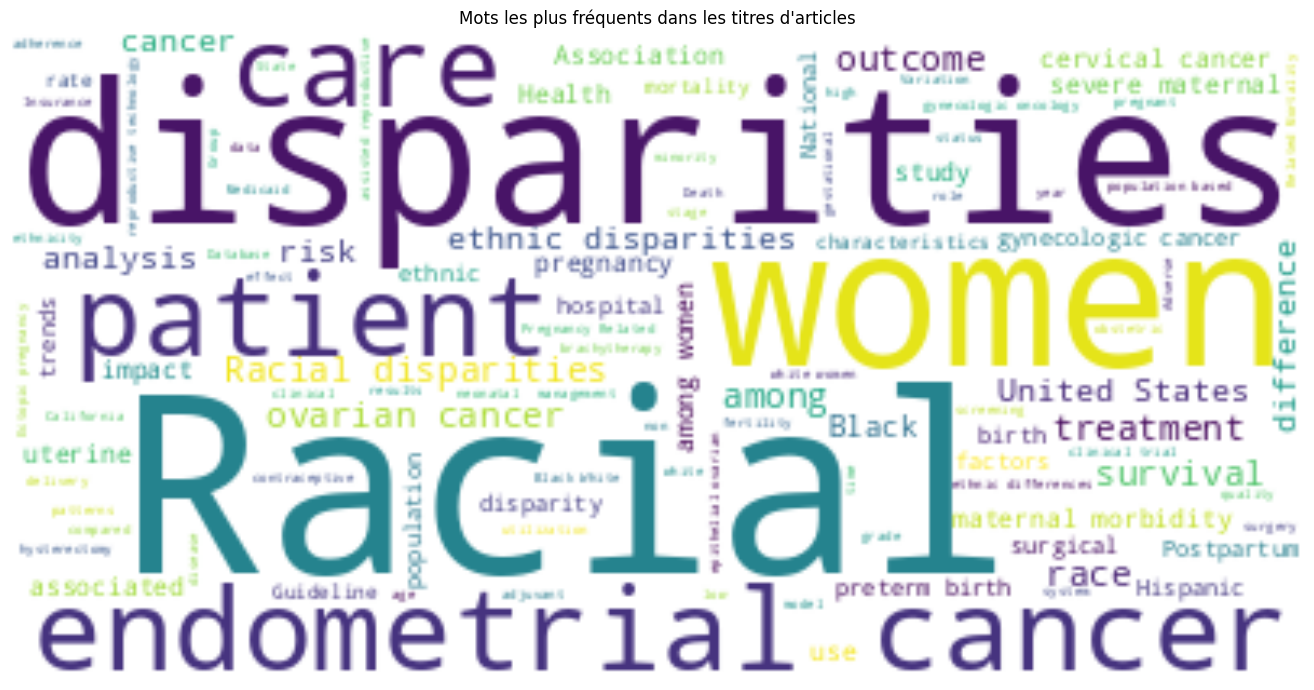

In [22]:
titles_text = " ".join(df["title"].dropna().tolist())

GraphicDrawer.draw_wordcloud(
    text=titles_text,
    max_words=150,
    title="Mots les plus fréquents dans les titres d'articles",
    figsize=(14, 7),
    background_color="white",
)

## 11. Répartition du focus thématique — `draw_pie_chart`

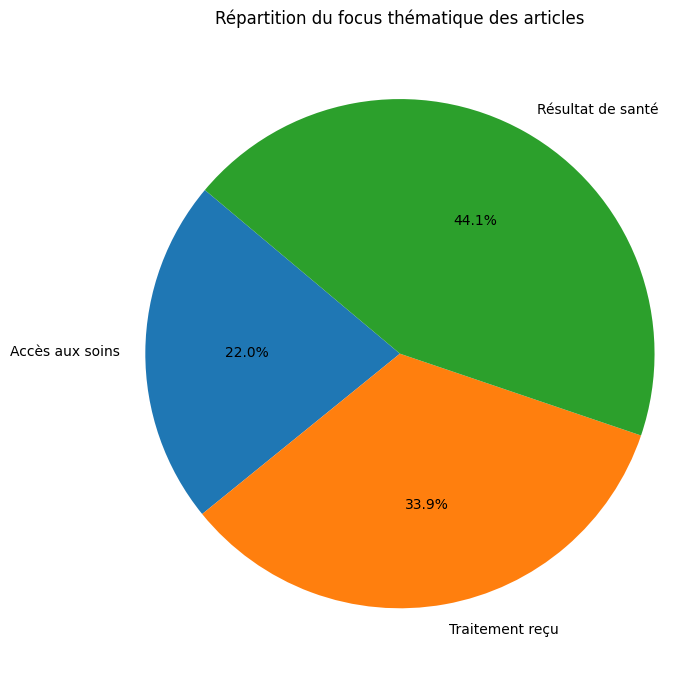

In [23]:
focus_cols = {
    "access_to_care":     "Accès aux soins",
    "treatment_received": "Traitement reçu",
    "health_outcome":     "Résultat de santé",
}
focus_counts = {
    label: int(df[col].sum())
    for col, label in focus_cols.items()
    if col in df.columns
}
focus_df = pd.DataFrame(list(focus_counts.items()), columns=["Category", "Count"])

GraphicDrawer.draw_pie_chart(
    data=focus_df,
    title="Répartition du focus thématique des articles",
    figsize=(7, 7),
)